In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import LogLocator, NullFormatter

In [102]:
dy = pd.read_csv("../2x2MCP-DY/outputs/production/aggregate_summary.csv")
dy = dy[dy["acceptance_fraction"] > 0].sort_values("mcp_mass_GeV")
print(len(dy))

63


In [103]:
meson = pd.read_csv("../2x2MCP-PythiaGen/outputs/meson_summary_50pt.csv")
meson = meson[meson["acceptance_fraction"] > 0].sort_values(["emitter_pdg", "mcp_mass_GeV"])

In [104]:
ALPHA = 1/137
parents = {
    111: (r"$\pi^0$", 0.1349768, 0.98823, 0),
    221: (r"$\eta$", 0.5478620, 0.39410, 0),
    331: (r"$\eta'$", 0.9577800, 0.0220, 0),
    113: (r"$\rho$", 0.7752600, 4.72e-5, 1),
    223: (r"$\omega$", 0.7826500, 7.36e-5, 1),
    333: (r"$\phi$", 1.0194610, 2.973e-4, 1),
    443: (r"$J/\psi$", 3.0969000, 5.971e-2, 1),
}

sigma_soft = meson.loc[
    meson["production_mode"] == 0, "sigma_gen_mb_mean"
].mean()

sigma_charm = meson.loc[
    meson["production_mode"] == 1, "sigma_gen_mb_mean"
].mean()

charm_scale = sigma_charm/sigma_soft

In [105]:
EPSILON = 1e-2
N_POT = 1.5e19
SIGMA_PP_TOTAL_MB = 38.4538
dy["N_accepted"] = (
    N_POT
    * EPSILON**2
    * dy["accepted_mcp_sigma_over_epsilon2_mb"]
    / SIGMA_PP_TOTAL_MB
)

In [106]:
meson_weighted = []

for pdg, (label, parent_mass, br_ref, kind) in parents.items():
    d = meson[meson["emitter_pdg"] == pdg].sort_values("mcp_mass_GeV").copy()
    r = (d["mcp_mass_GeV"]/parent_mass)**2

    if kind == 0:
        phase = np.maximum(0, 1 - 4*r)**3
    else:
        phase = np.sqrt(np.maximum(0, 1 - 4*r))*(1 + 2*r)

    scale = charm_scale if pdg == 443 else 1

    d["N_accepted"] = (
        N_POT * EPSILON**2 * ALPHA * br_ref * phase * scale
        * d["n_mcp_accepted"]/d["n_events_generated"]
    )

    d = d[d["N_accepted"] > 0]
    meson_weighted.append((label, d))

meson_total = (
    pd.concat([d[["mcp_mass_GeV", "N_accepted"]] for label, d in meson_weighted])
    .groupby("mcp_mass_GeV", as_index=False)["N_accepted"]
    .sum()
)


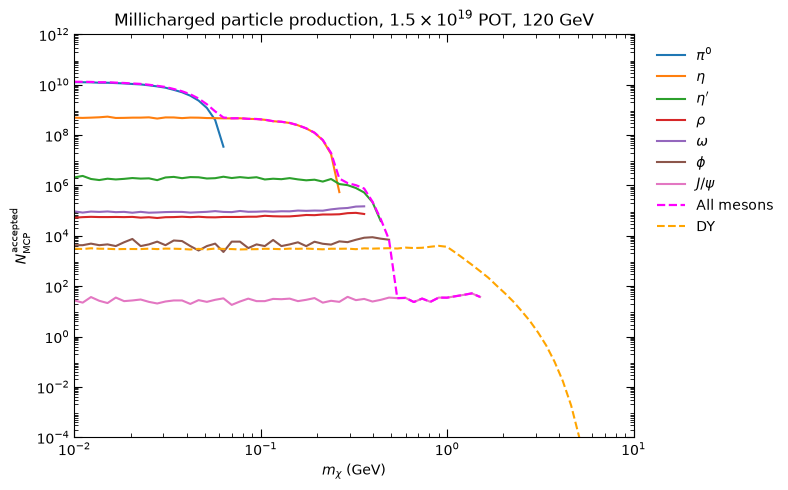

In [107]:
plt.figure(figsize=(8, 5))

for label, d in meson_weighted:
    plt.loglog(d["mcp_mass_GeV"], d["N_accepted"], label=label)

plt.loglog(meson_total["mcp_mass_GeV"], meson_total["N_accepted"],
           color="magenta", linewidth=1.6, linestyle="--", label="All mesons")
plt.loglog(dy["mcp_mass_GeV"], dy["N_accepted"],
           color="orange", linestyle="--", label="DY")

plt.xlim(1e-2, 1e1)
plt.ylim(1e-4, 1e12)

plt.xticks([1e-2, 1e-1, 1, 10])
plt.yticks(10.0**np.arange(-4, 13, 2))
plt.gca().set_xticks(np.concatenate([np.arange(2, 10)*10.0**i for i in range(-2, 1)]), minor=True)
plt.gca().set_yticks(np.concatenate([np.arange(2, 10)*10.0**i for i in range(-4, 12)]), minor=True)

plt.tick_params(which="major", direction="in", top=True, right=True, length=6)
plt.tick_params(which="minor", direction="in", top=True, right=True, length=3)

plt.xlabel(r"$m_\chi$ (GeV)")
plt.ylabel(r"$N_{\rm MCP}^{\rm accepted}$")
plt.title(r"Millicharged particle production, $1.5\times10^{19}$ POT, 120 GeV")
plt.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [66]:
meson_cross_sections = []

for pdg, (label, parent_mass, br_ref, kind) in parents.items():
    d = meson[meson["emitter_pdg"] == pdg].sort_values("mcp_mass_GeV").copy()
    r = (d["mcp_mass_GeV"]/parent_mass)**2

    if kind == 0:
        phase = np.maximum(0, 1 - 4*r)**3
    else:
        phase = np.sqrt(np.maximum(0, 1 - 4*r))*(1 + 2*r)

    scale = charm_scale if pdg == 443 else 1

    d["sigma_over_epsilon2_mb"] = (
        SIGMA_SOFT_MB * scale * ALPHA * br_ref * phase
        * d["n_mcp_pairs"]/d["n_events_generated"]
    )

    d = d[d["sigma_over_epsilon2_mb"] > 0]
    meson_cross_sections.append((label, d))

meson_total_cross_section = (
    pd.concat([
        d[["mcp_mass_GeV", "sigma_over_epsilon2_mb"]]
        for label, d in meson_cross_sections
    ])
    .groupby("mcp_mass_GeV", as_index=False)["sigma_over_epsilon2_mb"]
    .sum()
)



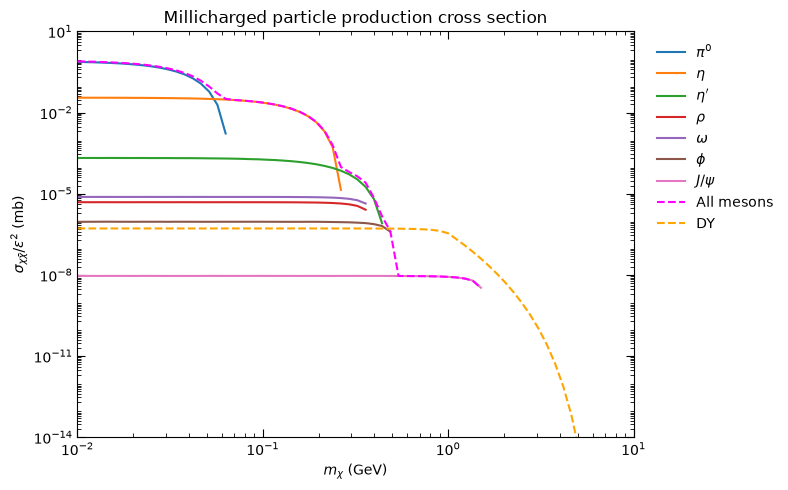

In [108]:
fig, ax = plt.subplots(figsize=(8, 5))

for label, d in meson_cross_sections:
    ax.plot(d["mcp_mass_GeV"], d["sigma_over_epsilon2_mb"], linewidth=1.5, label=label)

ax.plot(meson_total_cross_section["mcp_mass_GeV"],
        meson_total_cross_section["sigma_over_epsilon2_mb"],
        color="magenta", linewidth=1.5, linestyle="--", zorder=10, label="All mesons")

ax.plot(dy["mcp_mass_GeV"], dy["sigma_over_epsilon2_mb"],
        color="orange", linewidth=1.5, linestyle="--", label="DY")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e-2, 1e1)
ax.set_ylim(1e-14, 1e1)

ax.set_xticks([1e-2, 1e-1, 1, 10])
ax.set_yticks(10.0**np.arange(-14, 2, 3))
ax.set_xticks(np.concatenate([np.arange(2, 10)*10.0**i for i in range(-2, 1)]), minor=True)
ax.set_yticks(np.concatenate([np.arange(2, 10)*10.0**i for i in range(-14, 1)]), minor=True)

ax.tick_params(which="major", direction="in", top=True, right=True, length=6)
ax.tick_params(which="minor", direction="in", top=True, right=True, length=3)

ax.set_xlabel(r"$m_\chi$ (GeV)")
ax.set_ylabel(r"$\sigma_{\chi\bar{\chi}}/\epsilon^2$ (mb)")
ax.set_title("Millicharged particle production cross section")
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

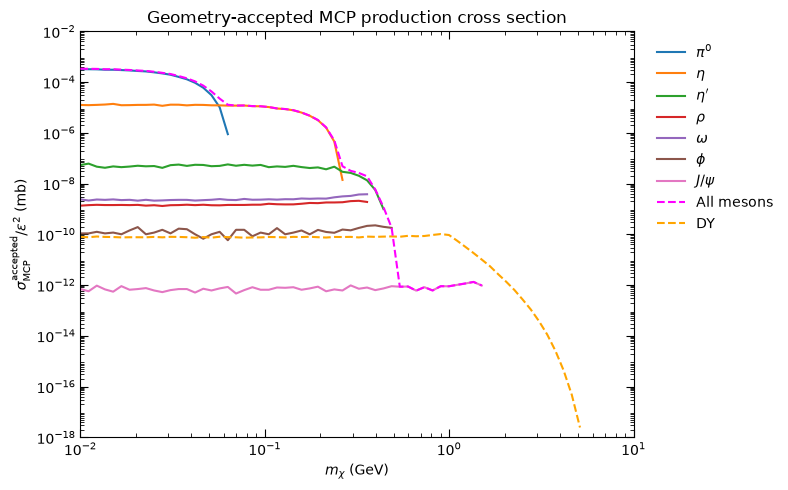

In [100]:
accepted = dy["accepted_mcp_sigma_over_epsilon2_mb"] > 0

fig, ax = plt.subplots(figsize=(8, 5))

for label, d in meson_weighted:
    ax.plot(d["mcp_mass_GeV"],
            d["N_accepted"]*SIGMA_PP_TOTAL_MB/(N_POT*EPSILON**2),
            linewidth=1.5, label=label)

ax.plot(meson_total["mcp_mass_GeV"],
        meson_total["N_accepted"]*SIGMA_PP_TOTAL_MB/(N_POT*EPSILON**2),
        color="magenta", linewidth=1.5, linestyle="--", zorder=10,
        label="All mesons")

ax.plot(dy.loc[accepted, "mcp_mass_GeV"],
        dy.loc[accepted, "accepted_mcp_sigma_over_epsilon2_mb"],
        color="orange", linewidth=1.5, linestyle="--", label="DY")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e-2, 1e1)
ax.set_ylim(1e-18, 1e-2)

ax.set_xticks([1e-2, 1e-1, 1, 10])
ax.set_yticks(10.0**np.arange(-18, -1, 2))
ax.set_xticks(np.concatenate([np.arange(2, 10)*10.0**i for i in range(-2, 1)]), minor=True)
ax.set_yticks(np.concatenate([np.arange(2, 10)*10.0**i for i in range(-18, -2)]), minor=True)

ax.tick_params(which="major", direction="in", top=True, right=True, length=6)
ax.tick_params(which="minor", direction="in", top=True, right=True, length=3)

ax.set_xlabel(r"$m_\chi$ (GeV)")
ax.set_ylabel(r"$\sigma_{\rm MCP}^{\rm accepted}/\epsilon^2$ (mb)")
ax.set_title("Geometry-accepted MCP production cross section")
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()